# Análise de Dados - Câncer de Pulmão

Análise exploratória do dataset de câncer de pulmão usando Python e Machine Learning

## Importação das Bibliotecas

Esta célula importa todas as bibliotecas necessárias para a análise:
- **pandas**: Manipulação e análise de dados tabulares
- **sklearn**: Algoritmos de machine learning (classificação, métricas, pré-processamento)
- **matplotlib.pyplot**: Criação de gráficos básicos
- **seaborn**: Visualizações estatísticas avançadas
- **numpy**: Operações numéricas e arrays

In [26]:
# Importar bibliotecas necessárias
import pandas as pd # Para trabalhar com dados tabulares
import numpy as np # Transformação dos dados
import matplotlib.pyplot as plt # Gráficos
import seaborn as sns # Gráficos
import seaborn as sb # Gráficos
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

try:
    import shap
except ModuleNotFoundError:
    shap = None


/Users/otoniel.isidoro/Documents/FIAP/TechChallenge/Tech_Challenge/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Descrição do Dataset

Este dataset contém informações sobre fatores de risco associados ao câncer de pulmão. As colunas representam:

- **Gênero**: M (masculino), F (feminino)
- **Idade**: Idade do paciente
- **Fumar**: SIM=2, NÃO=1
- **Dedos amarelos**: SIM=2, NÃO=1
- **Ansiedade**: SIM=2, NÃO=1
- **Pressão dos pares**: SIM=2, NÃO=1
- **Doença crônica**: SIM=2, NÃO=1
- **Fadiga**: SIM=2, NÃO=1
- **Alergia**: SIM=2, NÃO=1
- **Chiado no peito**: SIM=2, NÃO=1
- **Álcool**: SIM=2, NÃO=1
- **Tosse**: SIM=2, NÃO=1
- **Falta de ar**: SIM=2, NÃO=1
- **Dificuldade para engolir**: SIM=2, NÃO=1
- **Dor no peito**: SIM=2, NÃO=1
- **Câncer de pulmão**: SIM, NÃO

## 1. Carregamento dos Dados

Carregando o dataset survey lung cancer em um DataFrame do Pandas

In [27]:
# Carregar os dados
dados = pd.read_csv('dataset.csv', sep=',')

# Compatibilizar nomes de colunas entre versões do dataset
dados.rename(columns={
    'YELLOW_FINGERS': 'YELLOW FINGERS',
    'PEER_PRESSURE': 'PEER PRESSURE',
    'CHRONIC_DISEASE': 'CHRONIC DISEASE',
    'ALCOHOL_CONSUMING': 'ALCOHOL CONSUMING',
    'SHORTNESS_OF_BREATH': 'SHORTNESS OF BREATH',
    'SWALLOWING_DIFFICULTY': 'SWALLOWING DIFFICULTY',
    'CHEST_PAIN': 'CHEST PAIN'
}, inplace=True)

# Visualizar os primeiros registros
dados.head()

,GENDER,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


## Carregamento e Primeira Visualização dos Dados

Esta seção carrega o dataset CSV e mostra os primeiros registros para entender a estrutura dos dados.

## 2. Exploração Inicial dos Dados

Analisando as dimensões e verificando valores faltantes

In [28]:
# Dimensões do dataset (linhas, colunas)
print("Dimensões do dataset:")
dados.shape

Dimensões do dataset:


(3000, 16)

## Exploração Inicial dos Dados

Esta seção realiza uma análise preliminar do dataset:
- Verifica as dimensões (número de linhas e colunas)
- Identifica valores nulos/missing
- Mostra informações sobre tipos de dados
- Estatísticas descritivas básicas

In [29]:
print("\nValores nulos por coluna:")
dados.isnull().sum()


Valores nulos por coluna:


GENDER                   0
AGE                      0
SMOKING                  0
YELLOW FINGERS           0
ANXIETY                  0
PEER PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [30]:
print("\nInformações do dataset:")
dados.info()


Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 3000 non-null   str  
 1   AGE                    3000 non-null   int64
 2   SMOKING                3000 non-null   int64
 3   YELLOW FINGERS         3000 non-null   int64
 4   ANXIETY                3000 non-null   int64
 5   PEER PRESSURE          3000 non-null   int64
 6   CHRONIC DISEASE        3000 non-null   int64
 7   FATIGUE                3000 non-null   int64
 8   ALLERGY                3000 non-null   int64
 9   WHEEZING               3000 non-null   int64
 10  ALCOHOL CONSUMING      3000 non-null   int64
 11  COUGHING               3000 non-null   int64
 12  SHORTNESS OF BREATH    3000 non-null   int64
 13  SWALLOWING DIFFICULTY  3000 non-null   int64
 14  CHEST PAIN             3000 non-null   int64
 15  LUNG_CANCER            3

In [31]:
print("\nDescrição estatística dos dados numéricos:")
dados.describe()


Descrição estatística dos dados numéricos:


,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667
std,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,80.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [32]:
print("\nNúmero de registros duplicados:")
dados.duplicated().sum()


Número de registros duplicados:


2

## Limpeza de Dados

Esta seção trata da limpeza e preparação dos dados:
- Identifica e remove registros duplicados
- Garante qualidade dos dados para análise

In [33]:
dados.drop_duplicates(inplace=True)

In [34]:

print("\nContagem de valores únicos na coluna 'GENDER':")
print("Para indentificar o nuúmero de registros masculinos e femininos:")
dados['GENDER'].value_counts()


Contagem de valores únicos na coluna 'GENDER':
Para indentificar o nuúmero de registros masculinos e femininos:


GENDER
M    1512
F    1486
Name: count, dtype: int64

In [35]:

print("\nContagem de valores únicos na coluna 'LUNG_CANCER':")
print("Para identificar o número de registros com e sem câncer de pulmão:")
dados['LUNG_CANCER'].value_counts()


Contagem de valores únicos na coluna 'LUNG_CANCER':
Para identificar o número de registros com e sem câncer de pulmão:


LUNG_CANCER
YES    1517
NO     1481
Name: count, dtype: int64

In [36]:
print("Contagem dos valores únicos por idade:")
dados['AGE'].value_counts()

Contagem dos valores únicos por idade:


AGE
54    73
67    71
75    71
47    70
69    70
55    69
78    69
79    68
32    66
39    65
37    65
53    65
77    64
46    64
63    63
33    62
50    62
70    61
68    61
35    60
48    60
36    60
76    59
71    59
31    59
62    58
57    58
56    58
60    57
80    57
34    57
52    57
61    57
64    56
41    56
42    56
49    56
51    55
59    55
43    55
44    54
38    53
58    51
40    51
74    50
65    49
66    48
45    47
72    46
73    43
30    42
Name: count, dtype: int64

In [37]:
Total = len(dados)
temCancer = dados[dados["LUNG_CANCER"] == 'YES'].LUNG_CANCER.count()
naoTemCancer = dados[dados["LUNG_CANCER"] == 'NO'].LUNG_CANCER.count()

Percentual_tem_cancer = temCancer / Total 

print("Total de dados: ", Total)
print("Total de pessoas que não tem cancer: ", naoTemCancer)
print("Total de pessoas que tem cancer: ", temCancer)
print("Percentual que tem cancer: ", (round(Percentual_tem_cancer, 2)*100), "%")

Total de dados:  2998
Total de pessoas que não tem cancer:  1481
Total de pessoas que tem cancer:  1517
Percentual que tem cancer:  51.0 %


## Análise da Variável Alvo (Câncer de Pulmão)

Esta seção analisa a distribuição da variável dependente:
- Contagem de casos positivos e negativos
- Cálculo de percentuais
- Visualização com gráfico de pizza


Distribuição de câncer de pulmão:


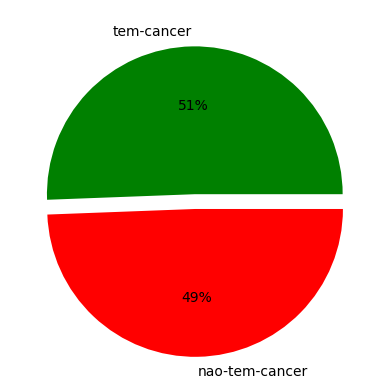

In [38]:

print("\nDistribuição de câncer de pulmão:")
categororias = ["tem-cancer", "nao-tem-cancer"]
plt.pie(dados["LUNG_CANCER"].value_counts(), labels = categororias, autopct = "%.0f%%", explode= (0, 0.1), colors = ("g", "r"))
plt.show()

In [39]:
totalTemCancer = dados[dados["LUNG_CANCER"] == 'YES']

## Análise dos Pacientes com Câncer

Esta seção foca nos pacientes diagnosticados com câncer:
- Filtra apenas casos positivos
- Mostra estatísticas descritivas dos fatores de risco
- Cria visualizações dos padrões encontrados

In [40]:
totalTemCancer.head()

,GENDER,AGE,SMOKING,YELLOW FINGERS,ANXIETY,PEER PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
5,F,58,1,1,1,2,2,2,2,1,2,2,1,1,2,YES
6,F,70,1,1,1,2,2,1,2,2,2,2,2,2,1,YES
11,F,60,2,2,1,1,1,1,2,2,2,1,1,2,1,YES


In [41]:

print("\nDescrição estatística dos registros com câncer de pulmão:")
totalTemCancer.describe().T


Descrição estatística dos registros com câncer de pulmão:


,count,mean,std,min,25%,50%,75%,max
AGE,1517.0,54.652604,14.907541,30.0,41.0,54.0,68.0,80.0
SMOKING,1517.0,1.498352,0.500162,1.0,1.0,1.0,2.0,2.0
YELLOW FINGERS,1517.0,1.520765,0.499733,1.0,1.0,2.0,2.0,2.0
ANXIETY,1517.0,1.487146,0.500000,1.0,1.0,1.0,2.0,2.0
PEER PRESSURE,1517.0,1.486486,0.499982,1.0,1.0,1.0,2.0,2.0
CHRONIC DISEASE,1517.0,1.504944,0.500140,1.0,1.0,2.0,2.0,2.0
FATIGUE,1517.0,1.490442,0.500073,1.0,1.0,1.0,2.0,2.0
ALLERGY,1517.0,1.510218,0.500060,1.0,1.0,2.0,2.0,2.0
WHEEZING,1517.0,1.477917,0.499677,1.0,1.0,1.0,2.0,2.0
ALCOHOL CONSUMING,1517.0,1.475939,0.499585,1.0,1.0,1.0,2.0,2.0


<Axes: xlabel='COUGHING', ylabel='count'>

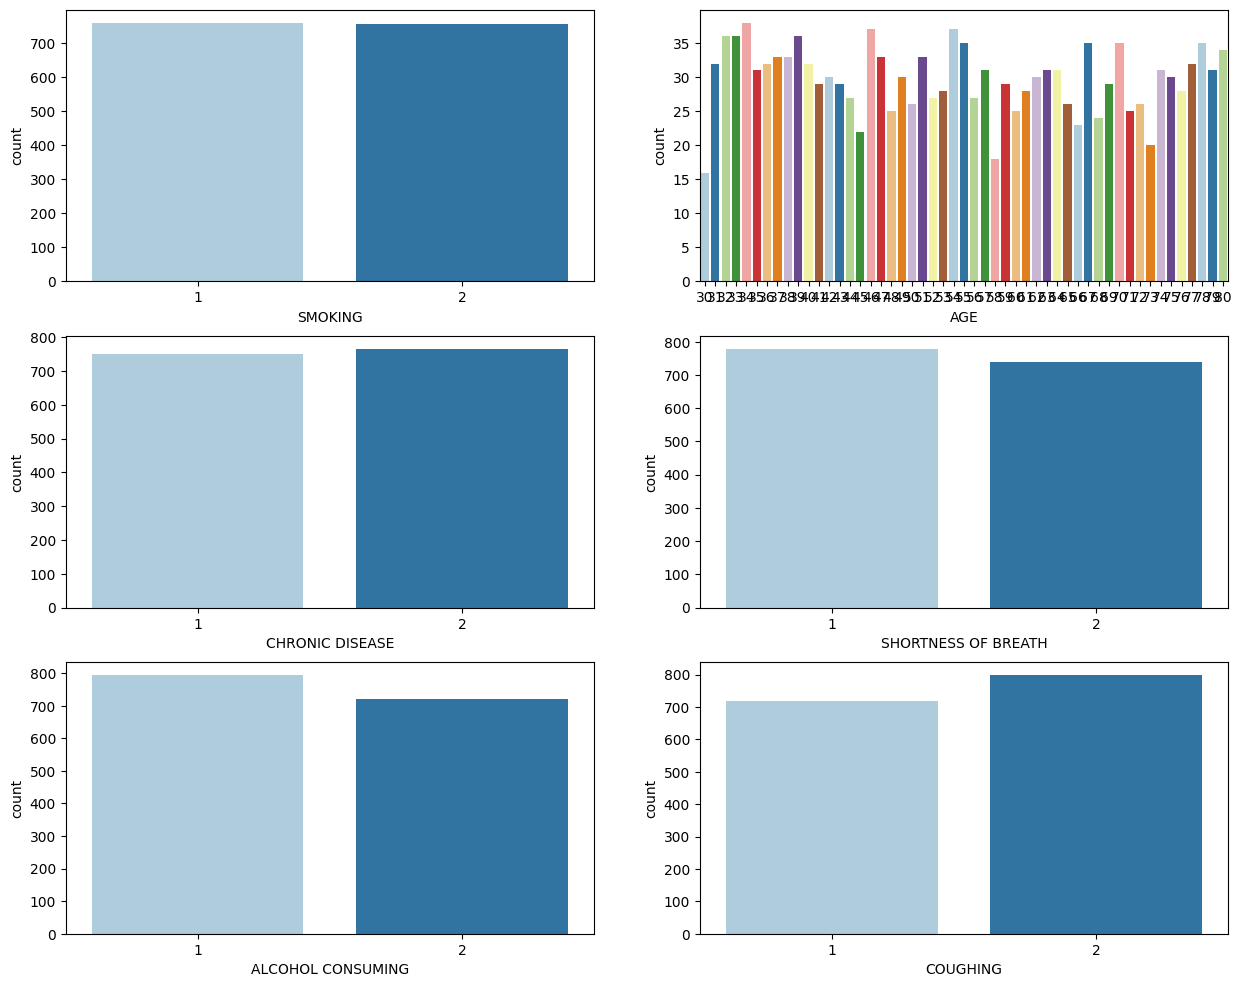

In [42]:
plt.figure(figsize = (15,12))

plt.subplot(3,2,1)
sns.countplot(x = "SMOKING", hue="SMOKING", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,2)
sns.countplot(x = "AGE", hue="AGE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,3)
sns.countplot(x = "CHRONIC DISEASE", hue="CHRONIC DISEASE", palette = "Paired", data = totalTemCancer, legend=False) 

plt.subplot(3,2,4)
sns.countplot(x = "SHORTNESS OF BREATH", hue="SHORTNESS OF BREATH", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,5)
sns.countplot(x = "ALCOHOL CONSUMING", hue="ALCOHOL CONSUMING", palette = "Paired", data = totalTemCancer, legend=False)

plt.subplot(3,2,6)
sns.countplot(x = "COUGHING", hue="COUGHING", palette = "Paired", data = totalTemCancer, legend=False)


/var/folders/t4/3td2bmbs6h38d0yjvn8hwfjn_473md/T/ipykernel_50577/1999815708.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')


<Axes: xlabel='LUNG_CANCER', ylabel='SMOKING'>

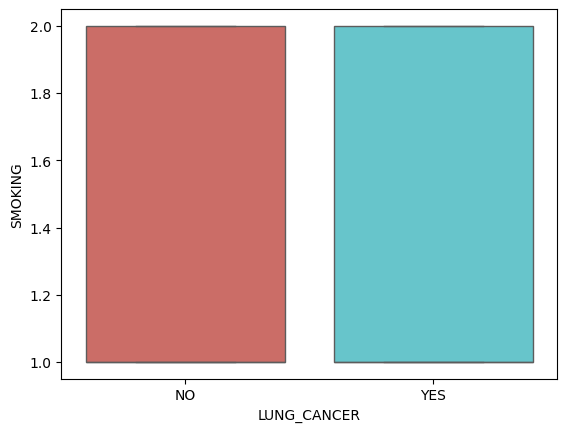

In [43]:


sb.boxplot(x='LUNG_CANCER', y='SMOKING', data=dados, palette='hls')

<Axes: xlabel='AGE'>

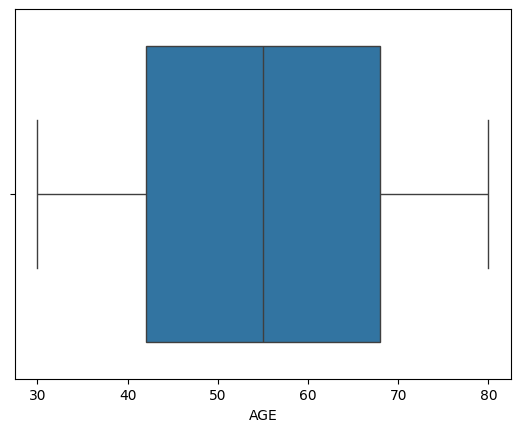

In [44]:
sb.boxplot(x=dados["AGE"])

## Visualizações dos Fatores de Risco

Esta seção cria gráficos para entender os fatores de risco:
- Gráficos de barras mostrando distribuição dos fatores
- Histogramas para variáveis numéricas
- Análise visual dos padrões nos pacientes com câncer

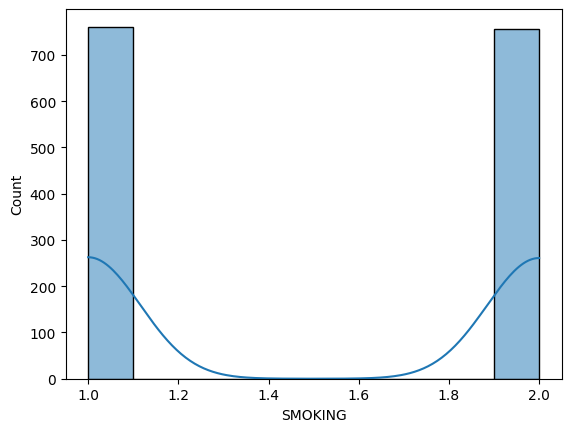

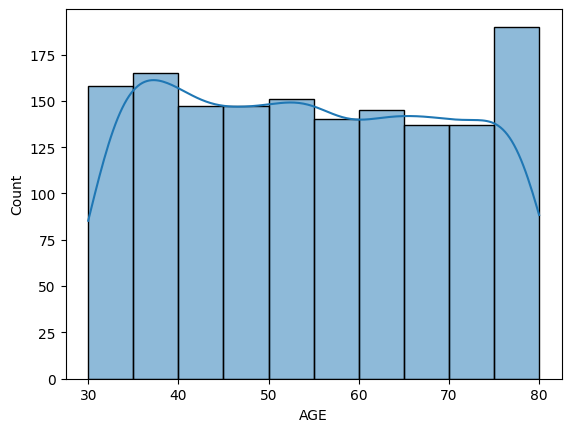

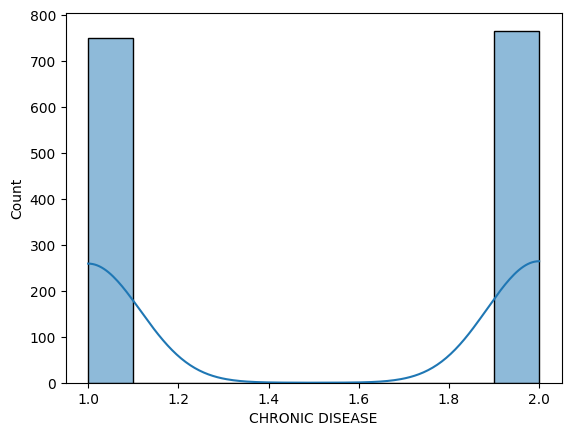

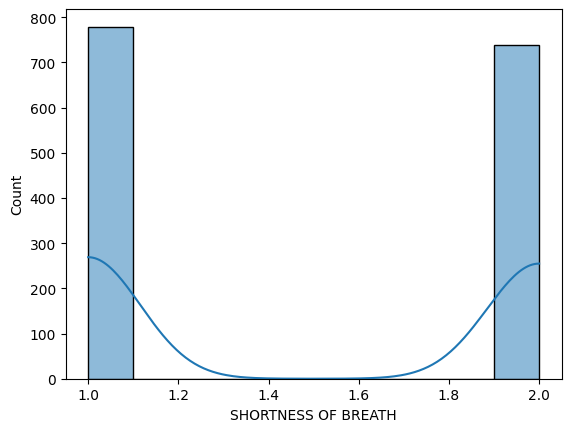

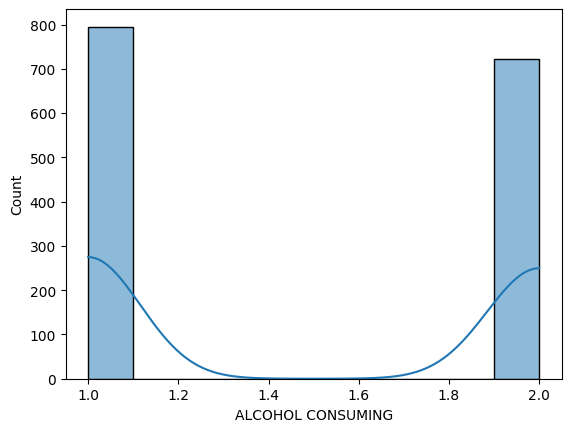

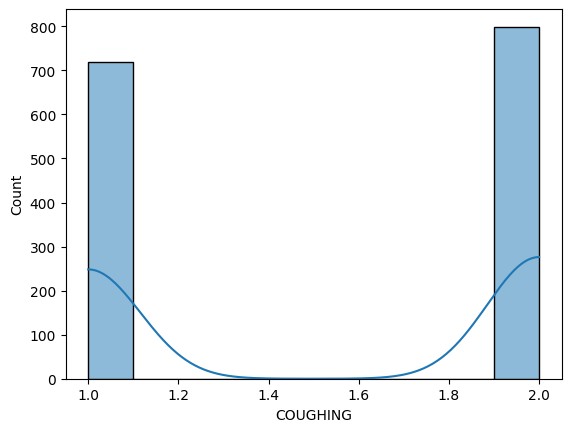

In [45]:
Colunas_Numericas = ["SMOKING", "AGE", "CHRONIC DISEASE", "SHORTNESS OF BREATH", "ALCOHOL CONSUMING", "COUGHING"]
for column in Colunas_Numericas:
    plt.figure()
    plot = totalTemCancer[column]
    sns.histplot(plot, bins=10, kde=True)
    plt.show()

In [46]:
dados_correlacao = dados.copy()

le_genero = LabelEncoder()
le_alvo = LabelEncoder()

dados_correlacao['GENDER'] = le_genero.fit_transform(dados_correlacao['GENDER'])
dados_correlacao['LUNG_CANCER'] = le_alvo.fit_transform(dados_correlacao['LUNG_CANCER'])

## Análise de Correlação

Esta seção analisa as relações entre os fatores de risco:
- Calcula correlação de Pearson entre variáveis numéricas
- Cria heatmap para visualizar associações
- Ordena as variáveis pela força de correlação com `LUNG_CANCER`
- Destaca visualmente quais fatores têm maior associação com o diagnóstico

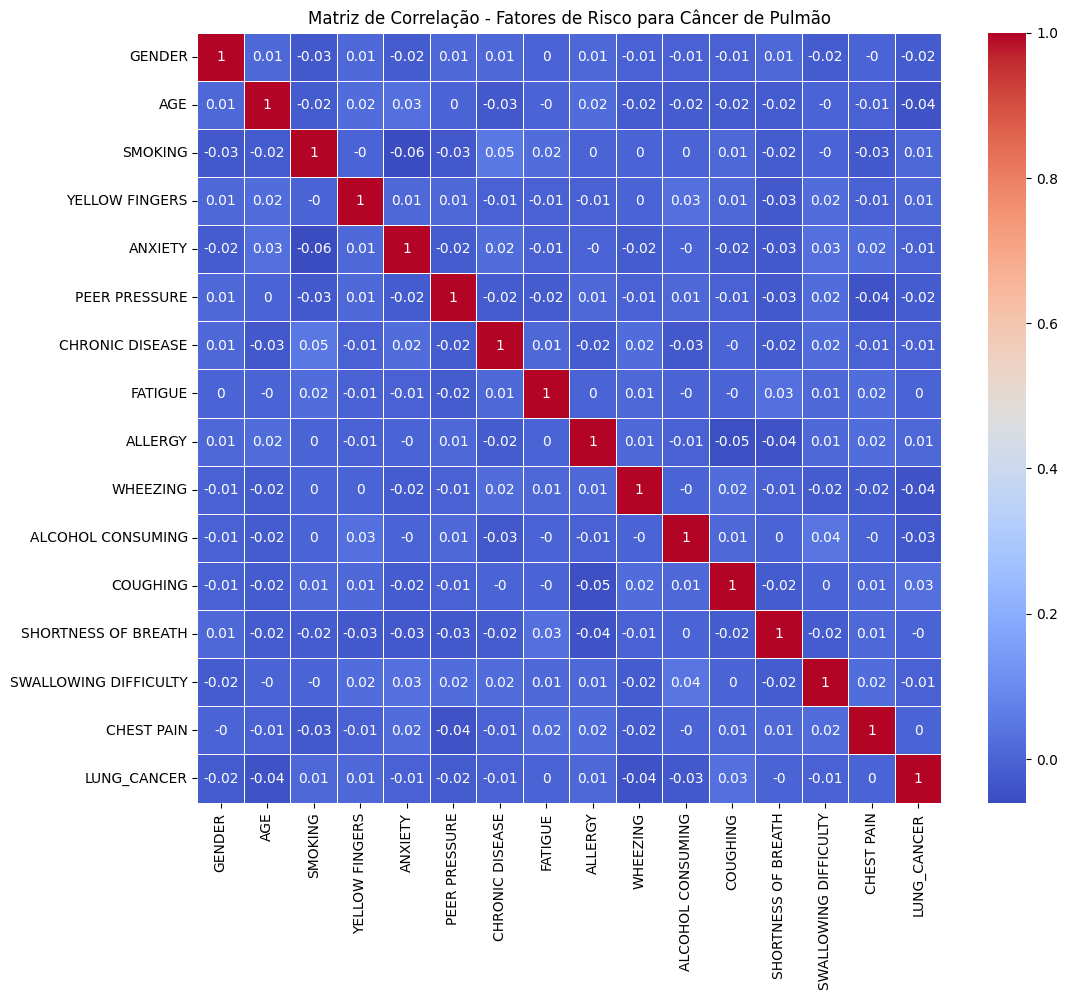

In [47]:
# Calcular correlação apenas para colunas numéricas
correlation_matrix = dados_correlacao.select_dtypes(include=[np.number]).corr().round(2)

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax, cmap='coolwarm')
plt.title('Matriz de Correlação - Fatores de Risco para Câncer de Pulmão')
plt.show()

Correlação das variáveis com LUNG_CANCER:


,correlacao
AGE,-0.04
WHEEZING,-0.04
ALCOHOL CONSUMING,-0.03
COUGHING,0.03
GENDER,-0.02
PEER PRESSURE,-0.02
SMOKING,0.01
YELLOW FINGERS,0.01
ANXIETY,-0.01
CHRONIC DISEASE,-0.01


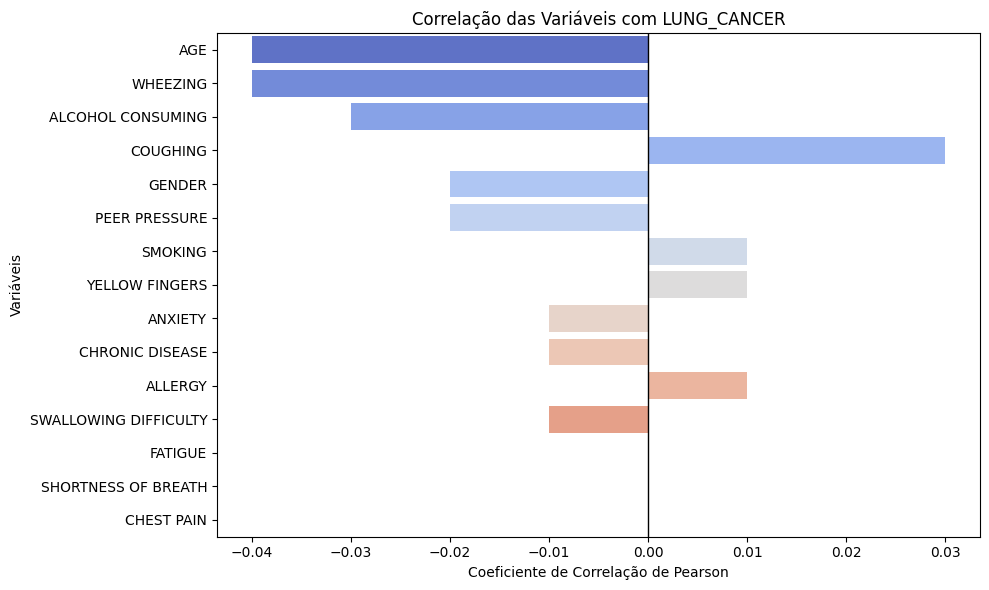

In [48]:
# Destacar a correlação das variáveis com a variável alvo
correlacao_com_cancer = correlation_matrix['LUNG_CANCER'].drop('LUNG_CANCER')
correlacao_com_cancer = correlacao_com_cancer.reindex(correlacao_com_cancer.abs().sort_values(ascending=False).index)

print('Correlação das variáveis com LUNG_CANCER:')
display(correlacao_com_cancer.to_frame(name='correlacao'))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlacao_com_cancer.values, y=correlacao_com_cancer.index, hue=correlacao_com_cancer.index, palette='coolwarm', legend=False)
plt.title('Correlação das Variáveis com LUNG_CANCER')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.ylabel('Variáveis')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

## Preparação para Modelagem

Nesta etapa, os dados são preparados para o treinamento dos modelos:
- Define-se a variável alvo e as variáveis explicativas
- Cria-se um pipeline de pré-processamento para variáveis categóricas e numéricas
- Realiza-se a separação entre treino e teste com estratificação da classe alvo

In [49]:
# Preparar os dados para a modelagem
dados_modelagem = dados.drop_duplicates().copy()

X = dados_modelagem.drop(columns=['LUNG_CANCER'])
y = dados_modelagem['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

colunas_categoricas = X.select_dtypes(include=['object', 'string']).columns.tolist()
colunas_numericas = [coluna for coluna in X.columns if coluna not in colunas_categoricas]

preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), colunas_categoricas),
        ('numericas', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), colunas_numericas)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Formato de X_train: {X_train.shape}')
print(f'Formato de X_test: {X_test.shape}')
print('Distribuição da classe alvo no treino:')
print(y_train.value_counts(normalize=True).rename(index={0: 'NO', 1: 'YES'}))
print('Distribuição da classe alvo no teste:')
print(y_test.value_counts(normalize=True).rename(index={0: 'NO', 1: 'YES'}))

Formato de X_train: (2398, 15)
Formato de X_test: (600, 15)
Distribuição da classe alvo no treino:
LUNG_CANCER
YES    0.505838
NO     0.494162
Name: proportion, dtype: float64
Distribuição da classe alvo no teste:
LUNG_CANCER
YES    0.506667
NO     0.493333
Name: proportion, dtype: float64


## Modelagem Preditiva

Foram escolhidas três técnicas de classificação para comparação:
- **Regressão Logística**: cria uma baseline linear interpretável
- **KNN**: pode capturar similaridade local entre pacientes
- **Random Forest**: lida bem com relações não lineares e fornece importância de variáveis

In [50]:
# Treinar diferentes modelos de classificação
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
}

modelos_treinados = {}
predicoes_teste = {}
resultados_modelos = []

for nome_modelo, estimador in modelos.items():
    pipeline_modelo = Pipeline([
        ('preprocessador', preprocessador),
        ('classificador', estimador)
    ])

    pipeline_modelo.fit(X_train, y_train)
    y_pred = pipeline_modelo.predict(X_test)

    modelos_treinados[nome_modelo] = pipeline_modelo
    predicoes_teste[nome_modelo] = y_pred
    resultados_modelos.append({
        'Modelo': nome_modelo,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

resultados_modelos_df = pd.DataFrame(resultados_modelos).sort_values(by=['F1-score', 'Recall', 'Accuracy'], ascending=False)
display(resultados_modelos_df.style.format({'Accuracy': '{:.3f}', 'Recall': '{:.3f}', 'F1-score': '{:.3f}'}))

melhor_modelo_nome = resultados_modelos_df.iloc[0]['Modelo']
print(f'Melhor modelo pelo critério principal (F1-score): {melhor_modelo_nome}')

/Users/otoniel.isidoro/Documents/FIAP/TechChallenge/Tech_Challenge/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/otoniel.isidoro/Documents/FIAP/TechChallenge/Tech_Challenge/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/otoniel.isidoro/Documents/FIAP/TechChallenge/Tech_Challenge/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/otoniel.isidoro/Documents/FIAP/TechChallenge/Tech_Challenge/.venv/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/otoniel.isid

,Modelo,Accuracy,Recall,F1-score
1,KNN,0.540,0.553,0.549
0,Regressão Logística,0.518,0.533,0.529
2,Random Forest,0.525,0.520,0.526


Melhor modelo pelo critério principal (F1-score): KNN


## Avaliação dos Modelos

As métricas escolhidas foram:
- **Accuracy**: visão geral de acerto
- **Recall**: importante em contexto de triagem, pois reduz o risco de falsos negativos
- **F1-score**: equilibra precisão e recall e foi usado como critério principal de comparação


Relatório de classificação - Regressão Logística
              precision    recall  f1-score   support

          NO       0.51      0.50      0.51       296
         YES       0.52      0.53      0.53       304

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.52      0.52       600



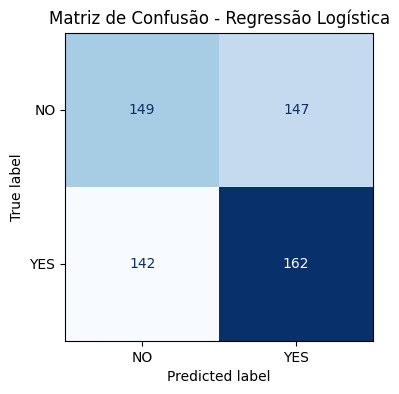


Relatório de classificação - KNN
              precision    recall  f1-score   support

          NO       0.53      0.53      0.53       296
         YES       0.55      0.55      0.55       304

    accuracy                           0.54       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.54      0.54      0.54       600



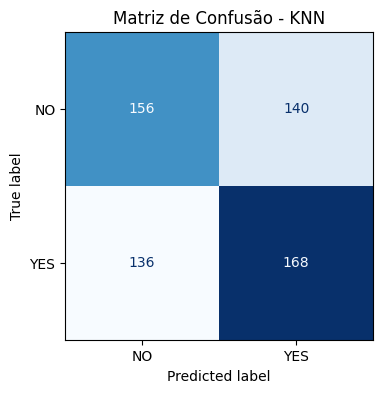


Relatório de classificação - Random Forest
              precision    recall  f1-score   support

          NO       0.52      0.53      0.52       296
         YES       0.53      0.52      0.53       304

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.52       600
weighted avg       0.53      0.53      0.53       600



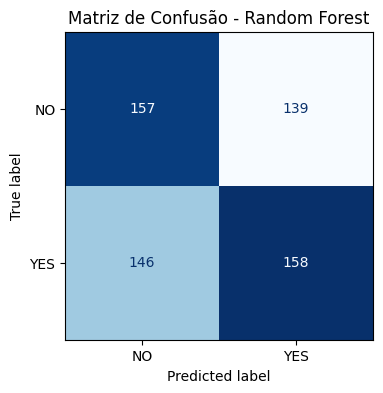

In [51]:
# Exibir relatório de classificação e matriz de confusão para cada modelo
for nome_modelo, y_pred in predicoes_teste.items():
    print(f'\nRelatório de classificação - {nome_modelo}')
    print(classification_report(y_test, y_pred, target_names=['NO', 'YES']))

    fig, ax = plt.subplots(figsize=(4, 4))
    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['NO', 'YES'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusão - {nome_modelo}')
    plt.show()

## Explicabilidade

Para interpretação das previsões, foi utilizada a Random Forest como modelo explicativo:
- **Feature importance** para identificar as variáveis mais relevantes globalmente
- **SHAP** para medir a contribuição média das variáveis nas previsões

,Variavel,Importancia
2,numericas__AGE,0.300401
15,numericas__CHEST PAIN,0.054619
5,numericas__ANXIETY,0.053721
9,numericas__ALLERGY,0.053468
13,numericas__SHORTNESS OF BREATH,0.052411
14,numericas__SWALLOWING DIFFICULTY,0.052041
8,numericas__FATIGUE,0.051877
4,numericas__YELLOW FINGERS,0.050882
6,numericas__PEER PRESSURE,0.050669
7,numericas__CHRONIC DISEASE,0.050114


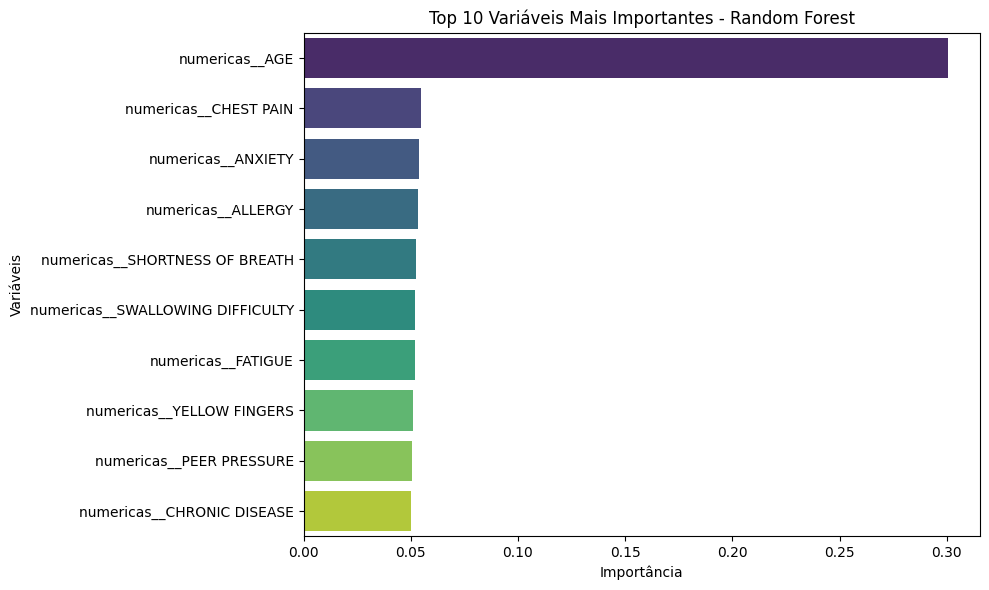

In [52]:
# Importância das variáveis com Random Forest
modelo_explicativo = modelos_treinados['Random Forest']
nomes_features = modelo_explicativo.named_steps['preprocessador'].get_feature_names_out()
importancias = modelo_explicativo.named_steps['classificador'].feature_importances_

importancias_df = pd.DataFrame({
    'Variavel': nomes_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(10)

display(importancias_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_df, x='Importancia', y='Variavel', hue='Variavel', palette='viridis', legend=False)
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

,Variavel,Impacto medio SHAP
2,numericas__AGE,0.024527
11,numericas__ALCOHOL CONSUMING,0.020511
10,numericas__WHEEZING,0.018922
12,numericas__COUGHING,0.016108
7,numericas__CHRONIC DISEASE,0.015462
6,numericas__PEER PRESSURE,0.014843
3,numericas__SMOKING,0.014648
4,numericas__YELLOW FINGERS,0.014163
15,numericas__CHEST PAIN,0.013789
14,numericas__SWALLOWING DIFFICULTY,0.013450


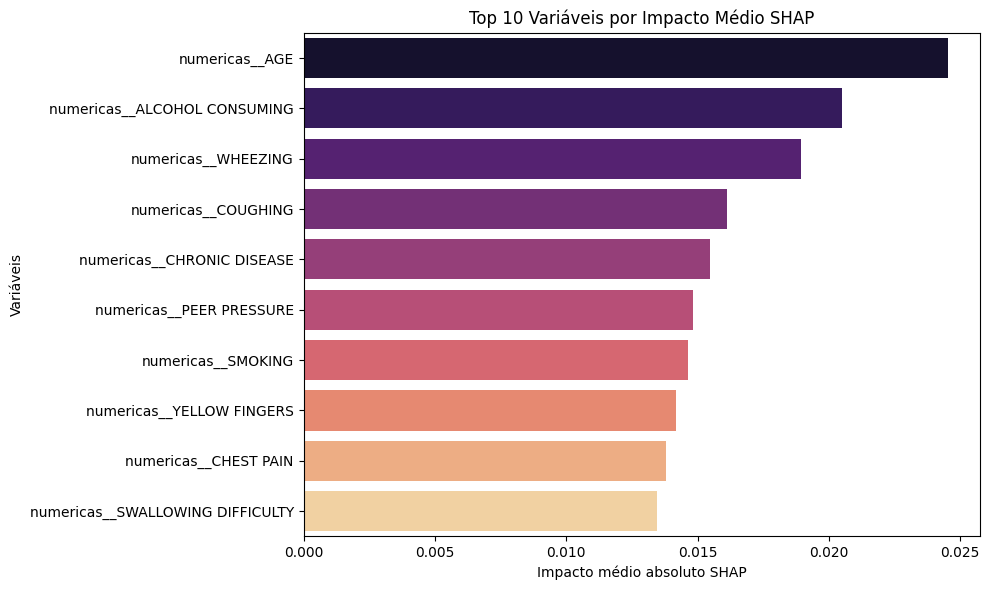

In [53]:
# Explicabilidade com SHAP
if shap is None:
    print('SHAP não está instalado no ambiente atual.')
else:
    X_test_transformado = modelo_explicativo.named_steps['preprocessador'].transform(X_test)
    if hasattr(X_test_transformado, 'toarray'):
        X_test_transformado = X_test_transformado.toarray()

    amostra_teste = X_test_transformado[: min(200, len(X_test_transformado))]
    explicador = shap.TreeExplainer(modelo_explicativo.named_steps['classificador'])
    shap_values = explicador.shap_values(amostra_teste)

    if isinstance(shap_values, list):
        shap_classe_positiva = shap_values[1]
    elif getattr(shap_values, 'ndim', 0) == 3:
        shap_classe_positiva = shap_values[:, :, 1]
    else:
        shap_classe_positiva = shap_values

    shap_importancia_df = pd.DataFrame({
        'Variavel': nomes_features,
        'Impacto medio SHAP': np.abs(shap_classe_positiva).mean(axis=0)
    }).sort_values(by='Impacto medio SHAP', ascending=False).head(10)

    display(shap_importancia_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=shap_importancia_df, x='Impacto medio SHAP', y='Variavel', hue='Variavel', palette='magma', legend=False)
    plt.title('Top 10 Variáveis por Impacto Médio SHAP')
    plt.xlabel('Impacto médio absoluto SHAP')
    plt.ylabel('Variáveis')
    plt.tight_layout()
    plt.show()

## Conclusões Críticas

O notebook agora cobre o fluxo técnico esperado para um projeto de classificação com Machine Learning: exploração dos dados, limpeza, pré-processamento, análise de correlação, separação entre treino e teste, treinamento com múltiplos modelos, avaliação por métricas e explicabilidade.

Do ponto de vista de desempenho, a comparação entre **Regressão Logística**, **KNN** e **Random Forest** permite escolher o modelo com melhor equilíbrio entre recall e F1-score. Em um contexto de triagem clínica, o **recall** é especialmente importante porque reduz a chance de deixar um caso positivo sem sinalização.

As etapas de explicabilidade com **feature importance** e **SHAP** ajudam a entender quais variáveis mais influenciam a previsão do modelo. Ainda assim, esse tipo de solução deve ser visto como **apoio à decisão**, nunca como substituto do julgamento médico.